**Verificando versión de TensorFlow**

In [ ]:
# Verificar que Keras/TensorFlow está disponible
import tensorflow as tf
from tensorflow import keras

print('TensorFlow version:', tf.__version__)
print('Keras disponible:', keras.__version__)
print('Todo listo para trabajar!')

TensorFlow version: 2.19.0
Keras disponible: 3.13.2
Todo listo para trabajar!


**Tensores**

In [ ]:
import tensorflow as tf

# 0D → Escalar (un solo número)
escalar = tf.constant(8)
print("Escalar:", escalar)
print("Dimensiones:", escalar.ndim)
print("Shape:", escalar.shape)


# 1D → Vector (lista de números)
vector = tf.constant([5, 10, 15, 20])
print("\nVector:", vector)
print("Dimensiones:", vector.ndim)
print("Shape:", vector.shape)


# 2D → Matriz (tabla)
matriz = tf.constant([[1, 2, 3],
                      [4, 5, 6]])
print("\nMatriz:")
print(matriz)
print("Dimensiones:", matriz.ndim)
print("Shape:", matriz.shape)


# 3D → Tensor (como una imagen RGB)
tensor_3d = tf.constant([[[255, 0, 0],
                          [0, 255, 0]],

                         [[0, 0, 255],
                          [255, 255, 0]]])

print("\nTensor 3D:")
print(tensor_3d)
print("Dimensiones:", tensor_3d.ndim)
print("Shape:", tensor_3d.shape)

Escalar: tf.Tensor(8, shape=(), dtype=int32)
Dimensiones: 0
Shape: ()

Vector: tf.Tensor([ 5 10 15 20], shape=(4,), dtype=int32)
Dimensiones: 1
Shape: (4,)

Matriz:
tf.Tensor(
[[1 2 3]
 [4 5 6]], shape=(2, 3), dtype=int32)
Dimensiones: 2
Shape: (2, 3)

Tensor 3D:
tf.Tensor(
[[[255   0   0]
  [  0 255   0]]

 [[  0   0 255]
  [255 255   0]]], shape=(2, 2, 3), dtype=int32)
Dimensiones: 3
Shape: (2, 2, 3)


| Tipo    | Ejemplo      | Dimensiones | Shape   |
| ------- | ------------ | ----------- | ------- |
| Escalar | 8            | 0D          | ()      |
| Vector  | [5,10,15,20] | 1D          | (4,)    |
| Matriz  | tabla        | 2D          | (2,3)   |
| Tensor  | imagen RGB   | 3D          | (2,2,3) |


**Red para Regresión (dataset California Housing)**


In [ ]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Cargar datos
data = fetch_california_housing()
X, y = data.data, data.target
print(f'Datos: {X.shape}  |  Variables de entrada: {X.shape[1]}')

Datos: (20640, 8)  |  Variables de entrada: 8


In [ ]:
import pandas as pd

df_X = pd.DataFrame(X, columns=data.feature_names)
df_X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
df_X.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0


**a) 64 -> 32 -> 1**

5 epocas

In [ ]:
# 2. Dividir en entrenamiento / validación
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Escalar variables
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# 4. Construir la red neuronal
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),  # capa de entrada
    layers.Dense(64, activation='relu'),     # capa oculta 1
    layers.Dense(32, activation='relu'),     # capa oculta 2
    layers.Dense(1)                          # salida: 1 número
])

# 5. Compilar
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=5,
        batch_size=32
    )

val_loss, val_mae = model.evaluate(X_val, y_val)

model.summary()  # ver arquitectura

Epoch 1/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8050 - mae: 0.6126 - val_loss: 0.4355 - val_mae: 0.4679
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3997 - mae: 0.4479 - val_loss: 0.4001 - val_mae: 0.4401
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3826 - mae: 0.4348 - val_loss: 0.3760 - val_mae: 0.4352
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3569 - mae: 0.4205 - val_loss: 0.3676 - val_mae: 0.4499
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3366 - mae: 0.4096 - val_loss: 0.3344 - val_mae: 0.4071
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3344 - mae: 0.4071


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,069 (31.52 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,380 (21.02 KB)

| Capa      | Cálculo        | Parámetros |
| --------- | -------------- | ---------- |
| Dense(64) | (8 × 64) + 64  | 576        |
| Dense(32) | (64 × 32) + 32 | 2080       |
| Dense(1)  | (32 × 1) + 1   | 33         |


**b) 32 -> 32 -> 1**

5 epocas

In [ ]:
# 4. Construir la red neuronal
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),  # capa de entrada
    layers.Dense(32, activation='relu'),     # capa oculta 1
    layers.Dense(32, activation='relu'),     # capa oculta 2
    layers.Dense(1)                          # salida: 1 número
])

# 5. Compilar
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=5,
        batch_size=32
    )

val_loss, val_mae = model.evaluate(X_val, y_val)

model.summary()  # ver arquitectura

Epoch 1/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9512 - mae: 0.6661 - val_loss: 0.4620 - val_mae: 0.4752
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4160 - mae: 0.4598 - val_loss: 0.3943 - val_mae: 0.4440
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3783 - mae: 0.4384 - val_loss: 0.3796 - val_mae: 0.4430
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3620 - mae: 0.4269 - val_loss: 0.3689 - val_mae: 0.4427
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3472 - mae: 0.4172 - val_loss: 0.3544 - val_mae: 0.4215
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3544 - mae: 0.4215


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,133 (16.15 KB)

 Trainable params: 1,377 (5.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,756 (10.77 KB)

**c) 32 -> 32 -> 1**

15 epocas

In [ ]:
# 4. Construir la red neuronal
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),  # capa de entrada
    layers.Dense(32, activation='relu'),     # capa oculta 1
    layers.Dense(32, activation='relu'),     # capa oculta 2
    layers.Dense(1)                          # salida: 1 número
])

# 5. Compilar
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32
    )

val_loss, val_mae = model.evaluate(X_val, y_val)

model.summary()  # ver arquitectura

Epoch 1/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9561 - mae: 0.6374 - val_loss: 0.4785 - val_mae: 0.4953
Epoch 2/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4170 - mae: 0.4590 - val_loss: 0.4034 - val_mae: 0.4537
Epoch 3/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3803 - mae: 0.4365 - val_loss: 0.3898 - val_mae: 0.4485
Epoch 4/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3652 - mae: 0.4274 - val_loss: 0.3734 - val_mae: 0.4450
Epoch 5/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3582 - mae: 0.4207 - val_loss: 0.3631 - val_mae: 0.4202
Epoch 6/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3767 - mae: 0.4190 - val_loss: 0.3505 - val_mae: 0.4277
Epoch 7/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3368 - mae: 0.4087 - val_loss: 0.3461 - val_mae: 0.4149
Epoch 8/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3302 - mae: 0.4035 - val_loss: 0.3364 - val_mae: 0.4131
Epoch 9/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,133 (16.15 KB)

 Trainable params: 1,377 (5.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,756 (10.77 KB)

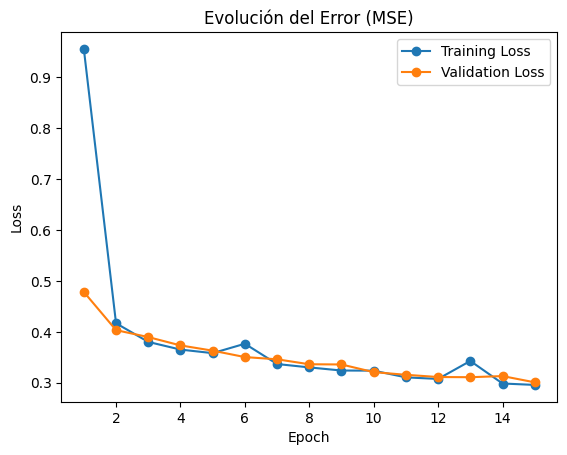

In [ ]:
import matplotlib.pyplot as plt

# Extraer datos del entrenamiento
loss = history.history['loss']
val_loss = history.history['val_loss']

mae = history.history['mae']
val_mae = history.history['val_mae']

epochs = range(1, len(loss) + 1)

# Gráfico de Loss
plt.figure()

plt.plot(epochs, loss, marker='o', label='Training Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')

plt.title('Evolución del Error (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Gráfico del MAE

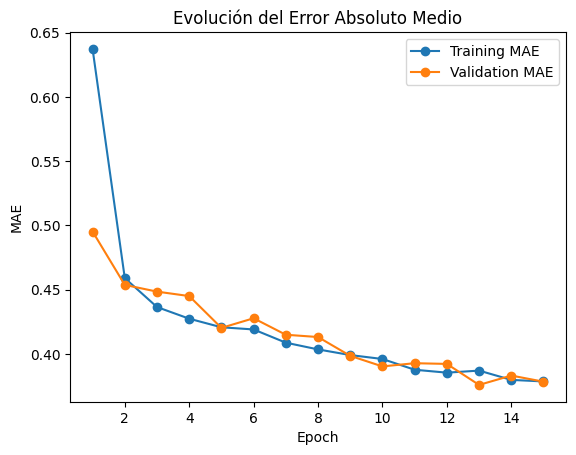

In [ ]:
plt.figure()

plt.plot(epochs, mae, marker='o', label='Training MAE')
plt.plot(epochs, val_mae, marker='o', label='Validation MAE')

plt.title('Evolución del Error Absoluto Medio')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.show()

In [ ]:
pip install scikeras

In [ ]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.4.2

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 72.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


d) Usando GridSearchCV

Nota: En redes neuronales no siempre es la opción más eficiente. Funciona bien para una demo o un problema pequeño, pero en problemas más grandes suele convenir Random Search, KerasTuner u Optuna.

In [ ]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from scikeras.wrappers import KerasRegressor
from tensorflow import keras
from tensorflow.keras import layers

# 1. Cargar datos
data = fetch_california_housing()
X, y = data.data, data.target

# 2. Separar datos
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Escalar
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# 4. Función que construye el modelo
def build_model(n_hidden=1, n_neurons=32, learning_rate=0.001):
    model = keras.Sequential()
    model.add(keras.Input(shape=(X_train.shape[1],)))

    for _ in range(n_hidden):
        model.add(layers.Dense(n_neurons, activation="relu"))

    model.add(layers.Dense(1))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )
    return model

# 5. Envolver modelo para scikit-learn
keras_reg = KerasRegressor(
    model=build_model,
    verbose=0
)
keras_reg._estimator_type = "regressor" # Fix: Explicitly set estimator type

# 6. Grilla de hiperparámetros
param_grid = {
    "model__n_hidden": [1, 2],
    "model__n_neurons": [32, 64],
    "epochs": [10],
    "batch_size": [32]
}

# 7. Grid Search
grid_search = GridSearchCV(
    estimator=keras_reg,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=3
)

grid_search.fit(X_train, y_train)

# 8. Resultados
print("Mejores parámetros:")
print(grid_search.best_params_)

print("\nMejor score (MAE negativo):")
print(grid_search.best_score_)

print("\nMejor modelo:")
print(grid_search.best_estimator_)

Mejores parámetros:
{'batch_size': 32, 'epochs': 10, 'model__n_hidden': 2, 'model__n_neurons': 64}

Mejor score (MAE negativo):
-0.39232504546848057

Mejor modelo:
KerasRegressor(
	model=<function build_model at 0x7eb0e5c58040>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=32
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=10
	model__n_hidden=2
	model__n_neurons=64
)


Probamos varias combinaciones de hiperparámetros usando Grid Search.
La mejor configuración fue una red con dos capas ocultas de 64 neuronas cada una.
Su error promedio fue cercano a 0.392 en la variable objetivo.

* batch_size es la cantidad de observaciones que la red procesa antes de actualizar sus pesos.

**Red para Clasificación (dataset Breast Cancer)**

Shape de X: (569, 30)
Shape de y: (569,)
Clases: ['malignant' 'benign']
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6637 - loss: 0.5353 - val_accuracy: 0.7368 - val_loss: 0.4426
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8308 - loss: 0.3900 - val_accuracy: 0.8947 - val_loss: 0.3563
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9253 - loss: 0.2994 - val_accuracy: 0.9474 - val_loss: 0.2825
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9473 - loss: 0.2238 - val_accuracy: 0.9474 - val_loss: 0.2209
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9582 - loss: 0.1658 - val_accuracy: 0.9386 - val_loss: 0.1776
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9736 - loss: 0.1315 - val_accuracy: 0.9386 - val_loss: 0.1505
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9780 - loss: 0.1076 - val_accuracy: 0.9474 - val_loss: 0.1370
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s

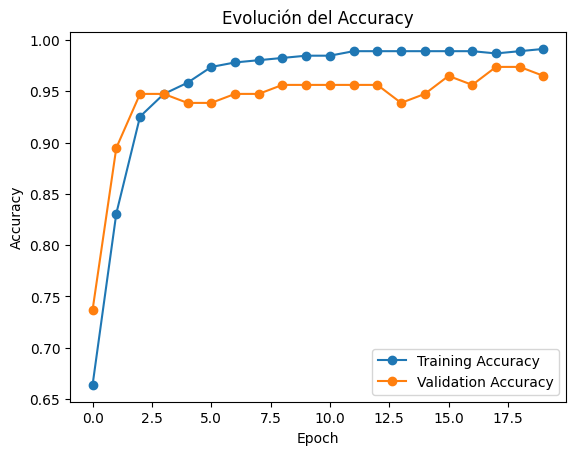

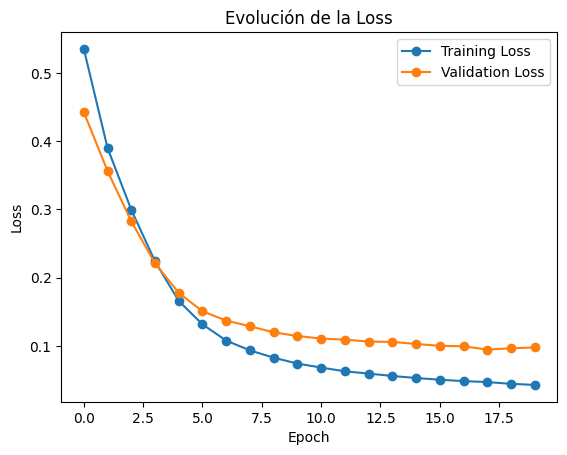

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_87 (Dense)                │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,613 (18.02 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,076 (12.02 KB)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Cargar datos
data = load_breast_cancer()
X, y = data.data, data.target

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Clases:", data.target_names)

# 2. Separar entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Escalar variables
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# 4. Construir la red neuronal
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),   # 30 variables de entrada
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')     # salida binaria
])

# 5. Compilar
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 6. Entrenar
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

# 7. Evaluar
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"\nLoss en validación: {loss:.4f}")
print(f"Accuracy en validación: {accuracy:.4f}")

# 8. Predicciones
y_prob = model.predict(X_val)
y_pred = (y_prob > 0.5).astype(int)

# 9. Matriz de confusión
cm = confusion_matrix(y_val, y_pred)
print("\nMatriz de confusión:")
print(cm)

# 10. Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(y_val, y_pred, target_names=data.target_names))

# 11. Gráfico accuracy
plt.figure()
plt.plot(history.history['accuracy'], marker='o', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.title('Evolución del Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 12. Gráfico loss
plt.figure()
plt.plot(history.history['loss'], marker='o', label='Training Loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')
plt.title('Evolución de la Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 13. Resumen del modelo
model.summary()

**Usando Random Search**

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from scikeras.wrappers import KerasClassifier
from tensorflow import keras
from tensorflow.keras import layers

# 1. Cargar datos
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Separar entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Escalar
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# 4. Función para construir el modelo
def build_model(n_hidden=1, n_neurons=32, learning_rate=0.001, dropout_rate=0.0):
    model = keras.Sequential()
    model.add(keras.Input(shape=(X_train.shape[1],)))

    for _ in range(n_hidden):
        model.add(layers.Dense(n_neurons, activation="relu"))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation="sigmoid"))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# 5. Envolver en SciKeras
keras_clf = KerasClassifier(
    model=build_model,
    verbose=0
)

# 6. Espacio de búsqueda aleatoria
param_dist = {
    "model__n_hidden": [1, 2, 3],
    "model__n_neurons": [16, 32, 64, 128],
    "model__learning_rate": [0.01, 0.001, 0.0005],
    "model__dropout_rate": [0.0, 0.2, 0.3],
    "batch_size": [16, 32, 64],
    "epochs": [10, 20, 30]
}

# 7. Random Search
random_search = RandomizedSearchCV(
    estimator=keras_clf,
    param_distributions=param_dist,
    n_iter=10,              # número de combinaciones aleatorias a probar
    scoring="accuracy",
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# 8. Mostrar mejores hiperparámetros
best_params = random_search.best_params_
print("Mejores parámetros:")
print(random_search.best_params_)

print("\nMejor accuracy promedio:")
print(random_search.best_score_)

Mejores parámetros:
{'model__n_neurons': 128, 'model__n_hidden': 2, 'model__learning_rate': 0.0005, 'model__dropout_rate': 0.3, 'epochs': 20, 'batch_size': 32}

Mejor accuracy promedio:
0.9780556523759731


**Construir el modelo con el resultado anterior**

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7956 - loss: 0.5200 - val_accuracy: 0.9474 - val_loss: 0.3419
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9297 - loss: 0.2910 - val_accuracy: 0.9561 - val_loss: 0.2115
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9495 - loss: 0.1847 - val_accuracy: 0.9649 - val_loss: 0.1615
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9670 - loss: 0.1357 - val_accuracy: 0.9649 - val_loss: 0.1336
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9648 - loss: 0.1168 - val_accuracy: 0.9737 - val_loss: 0.1171
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9780 - loss: 0.1037 - val_accuracy: 0.9737 - val_loss: 0.1097
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9758 - loss: 0.0941 - val_accuracy: 0.9737 - val_loss: 0.1007
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9758 - loss: 0.0853 - val_accuracy: 0.9825 - val_loss


Matriz de confusión:
[[41  1]
 [ 4 68]]

Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



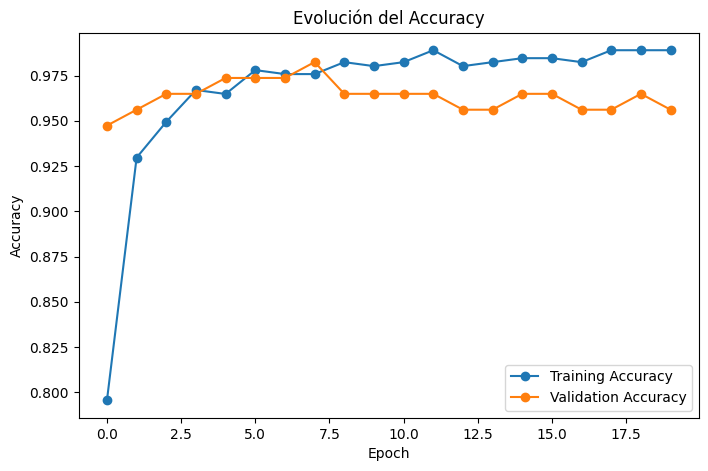

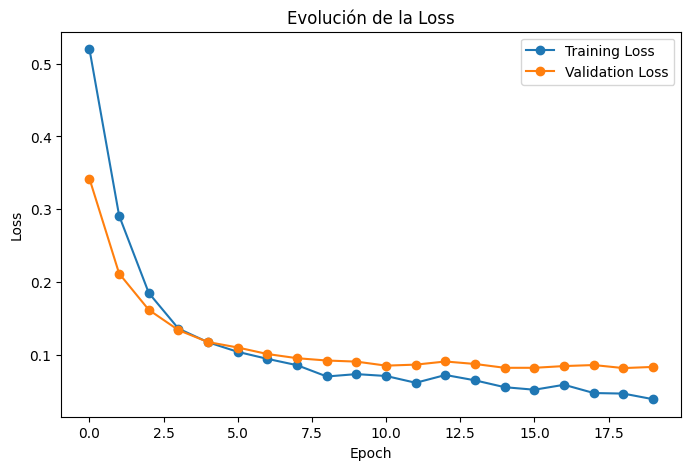


Resumen del mejor modelo:


Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_96 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,829 (241.52 KB)

 Trainable params: 20,609 (80.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 41,220 (161.02 KB)

In [ ]:
# 9. Construir el mejor modelo
best_model = build_model(
    n_hidden=best_params["model__n_hidden"],
    n_neurons=best_params["model__n_neurons"],
    learning_rate=best_params["model__learning_rate"],
    dropout_rate=best_params["model__dropout_rate"]
)

# 10. Entrenar el mejor modelo
history = best_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    verbose=1
)

# 11. Evaluar el modelo
loss, accuracy = best_model.evaluate(X_val, y_val, verbose=0)
print("\nLoss en validación:", round(loss, 4))
print("Accuracy en validación:", round(accuracy, 4))

# 12. Predicciones
y_prob = best_model.predict(X_val, verbose=0)
y_pred = (y_prob > 0.5).astype(int)

# 13. Matriz de confusión
cm = confusion_matrix(y_val, y_pred)
print("\nMatriz de confusión:")
print(cm)

# 14. Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(y_val, y_pred, target_names=data.target_names))

# 15. Gráfico de accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Evolución del Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 16. Gráfico de loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Evolución de la Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 17. Resumen del modelo
print("\nResumen del mejor modelo:")
best_model.summary()